# Problem set 3

## Topics covered in class: 

- GLS (general estimates for linear problem, not very used in practice since solution is often inconsistent or infeasible)
- Regressor endegoneity (opposite of exogeneity, this is when cov(x_i, e_i)=/=0 -> OLS estimates are inconsistent (estimate does not converge to true value) since moment condition E[x_i*e_i] =/= 0 -> innovation is now correlated with the regressor, orthogonality breaks and OLS becomes inconsistent). 3 main cases: LDV when correlated errors, omitted variable correlated with the factor, don't account for measurement errors.
- Endogeneity -> consistency (Instrumental Variables)


In [2]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.9 MB/s eta 0:00:0000:0100:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 8.1 MB/s eta 0:00:0000:0100:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from math import pi

from tqdm import tqdm

## Exercise 1

This exercise digs into the effect of fitting a AR(1) model when the data generating process is
an ARMA(1,1) process. This model mispecification gives rise to autocorrelation of the error and 
breaks the exogeneity assumptions: the OLS estimator in this case is biaised and inconsitent. Let 
check that with Monte Carlo simulations.

In [2]:
# OLS function

def ols(X, y, include_constant=False):
    '''
    This function outputs OLS point estimators, the OLS and White standard errors, the R^2 and adjusted
    version and the value of the log-likelihood at the optimum.

    Inputs:
    X -> np 2D array of n observations x k predictors 
    y -> np array of n observations
    include_constant -> boolean, whether to add a constant column if not present

    Outputs: 
    A dictionary with desired values

    Model Assumptions:
    - Observations (y_i, x_i) are iid 
    - The true relationship is linear ie y_i = x_i*beta + e_i
    - Errors are exogenous
    - The second moments of y_i and x_i are finite
    - The second moment matrix of x_i, Q_xx = E[x_i*x_i.T] is invertible
    '''

    out = {}
    n = X.shape[0]
    k = X.shape[1]

    # Handle constant option - check if any column is constant
    has_constant = np.any(np.ptp(X, axis=0) == 0)

    if not has_constant and include_constant:
        X = np.column_stack((np.ones(n), X))
        k = X.shape[1]  # Update k after adding constant
        has_constant = True

    out["n_observations"] = n
    out["n_predictors"] = k
    out["has_constant"] = has_constant

    # Beta Estimates
    XtX = X.T @ X
    invertible = np.linalg.matrix_rank(XtX) == XtX.shape[0]
    if invertible:
        XtX_inv = np.linalg.inv(XtX)
        beta_hat = XtX_inv @ X.T @ y
        out["beta_hat"] = beta_hat
    else:
        raise ValueError("The second moment matrix is not invertible")

    # Residuals
    eps = y - X @ beta_hat
    out["residuals"] = eps
    out["squared_residuals"] = eps ** 2

    # R-Squared
    y_mean = np.mean(y)
    ss_total = np.sum((y - y_mean) ** 2)
    ss_residual = np.sum(eps ** 2)
    r_squared = 1 - (ss_residual / ss_total)
    out["min_sse"] = ss_residual
    out["r_squared"] = r_squared

    # Adjusted R-Squared (k includes constant if present)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k)
    out["adj_r_squared"] = adj_r_squared

    # OLS Standard Error estimate (assuming homoskedasticity)
    sigma2_hat = ss_residual / (n - k)
    V_ols = sigma2_hat * XtX_inv
    std_ols = np.sqrt(np.diag(V_ols))
    out["std_ols_estimate"] = std_ols
    out["sigma2_hat"] = sigma2_hat

    # White (heteroskedasticity-robust) Standard Error estimate
    XD = X * (eps ** 2)[:, None]
    XDX = X.T @ XD
    V_white = XtX_inv @ XDX @ XtX_inv
    std_white = np.sqrt(np.diag(V_white))
    out["std_white_estimate"] = std_white

    # Log-likelihood maximum (assuming normal errors)
    max_logL = -n * (np.log(2 * pi) + 1) / 2 - n * np.log(ss_residual / n) / 2
    out["max_logL"] = max_logL

    # Information Criteria (k+1 parameters: k betas + sigma^2)
    out["AIC"] = -2 * max_logL + 2 * (k + 1)
    out["BIC"] = -2 * max_logL + np.log(n) * (k + 1)

    # Projection matrices
    P = X @ XtX_inv @ X.T
    M = np.eye(n) - P
    out["P_projection"] = P
    out["M_projection"] = M
    out["PM_is_zero"] = np.allclose(P @ M, 0)

    # BLP moment condition E(ex) = 0
    e_xe = (X.T @ eps) / n
    e_xe_is_0 = np.allclose(e_xe, 0, atol=1e-8)
    out["e_xe"] = e_xe
    out["e_xe_is_0"] = e_xe_is_0

    # Condition number for singularity
    Q_xx = X.T @ X / n
    condition_number = np.linalg.cond(Q_xx)
    out["condition_number"] = condition_number

    # t-statistics (OLS and White)
    out["t_stat_ols"] = beta_hat / std_ols
    out["t_stat_white"] = beta_hat / std_white

    return out

# ACF function

def ACF(series, max_lag):
    """
    rho_k = sum (x_t-mean)(x_{t-k}-mean) / sum (x_t-mean)^2
    """
    x = pd.Series(series).dropna().to_numpy()
    T = len(x)
    x_mean = np.mean(x)
    denom = np.sum((x - x_mean) ** 2)
    acf_vals = []
    for k in range(max_lag + 1):
        num = 0.0
        for t in range(k, T):
            num += (x[t] - x_mean) * (x[t - k] - x_mean)
        acf_vals.append(num / denom)
    return np.array(acf_vals)

Number of simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

Number of simulations: 100%|██████████| 1000/1000 [00:45<00:00, 21.93it/s]


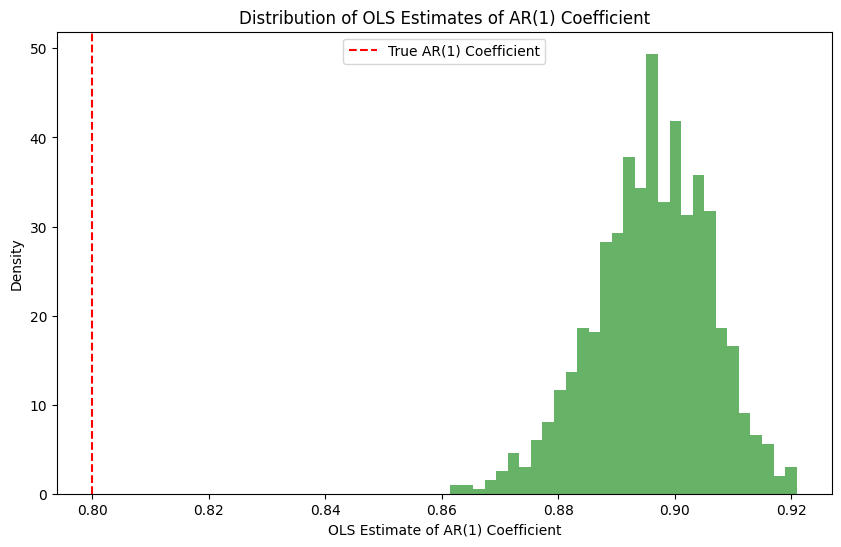

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

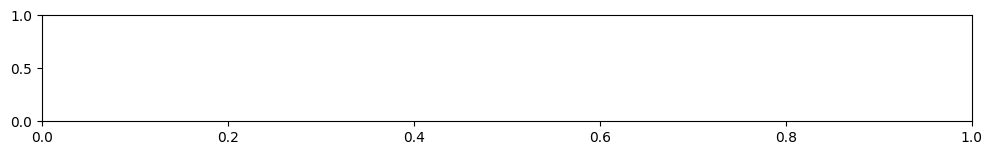

In [14]:
# Number of simulations to run
T = 1000

# Sample size for each simulation
N = 1000

# DGP parameters (ARMA(1,1))
phi = 0.8 # AR(1) coefficient
theta = 0.7 # MA(1) coefficient

mean = 0.0 # Mean of the error term
sigma_e = 1.0 # Standard deviation of the error term

# Store OLS estimates of the AR(1) coefficient from each simulation
ols_estimates_1 = np.zeros(T)
iv_results = np.zeros(T)
acf_residuals_all_1 = np.zeros((T, 21)) # Store ACF of residuals for each simulation

for i in tqdm(range(T), desc="Number of simulations"):
    # Generate error terms
    e = np.random.normal(loc=mean, scale=sigma_e, size=N)

    #Initialize the time series array
    y = np.zeros(N)

    # Generate the ARMA(1,1) time series
    for t in range(1, N):
        y[t] = phi * y[t-1] + e[t] + theta * e[t-1]

    # Model the ARMA(1,1) process by an AR(1) process and compute the OLS estimate of the AR(1) coefficient
    y_lag1 = y[:-1] # Lagged values
    Y = y[1:] # Current values
    results = ols(y_lag1.reshape(-1, 1), Y, include_constant=False)

    # Store the OLS estimate of the AR(1) coefficient
    ols_estimates_1[i] = results["beta_hat"][0]

    # Compute the autororelation of the residuals to check for misspecification
    residuals = results["residuals"]
    acf_residuals_all_1[i, :] = ACF(residuals, max_lag=20)

    # Comptute the IV estimate of the AR(1) coefficient using y_t-2
    y_lag2 = y[:-2].reshape(-1, 1) # Instrument: y_{t-2}
    y_lag1 = y[1:-1].reshape(-1, 1) # Endogenous regressor: y_{t-1}
    y = y[2:].reshape(-1, 1) # Current values (column, same shape as lags)

    iv_results[i] = (y_lag2.T @ y / (y_lag2.T @ y_lag1)).item()


# Plot histogram of OLS estimates
plt.figure(figsize=(10, 6))
plt.hist(ols_estimates_1, bins=30, density=True, alpha=0.6, color='g')
plt.title('Distribution of OLS Estimates of AR(1) Coefficient')
plt.xlabel('OLS Estimate of AR(1) Coefficient')
plt.ylabel('Density')
plt.axvline(x=phi, color='r', linestyle='--', label='True AR(1) Coefficient')
plt.legend()
plt.show()

# Plot ACF of residuals for a few simulations
plt.figure(figsize=(12, 8))
for i in range(5):
    plt.subplot(5, 1, i+1)
    plt.stem(range(21), acf_residuals_all_1[i, :], use_line_collection=True)
    plt.title(f'ACF of Residuals - Simulation {i+1}')
    plt.xlabel('Lag')
    plt.ylabel('ACF')
    plt.axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()


### Analysis of the OLS estimators for AR(1)

The estimator is positively biaised. The distribution is also skewed, which contradicts the asymptotic normal distribution. Both these observations hints that the exogeneity moment condition E[y_i-1,e_i] = 0 breaks

### Analysis of the ACF of the errors

The error is consistently serially correlated with a positive correlation at lag=1. Since the AR(1) contains a LDV, the exogeneity moment condition breaks and the OLS estimator is biaised and inconsistent as expected.


To fix for the inconsitency, we introduce an instrument variable that is both correlated with the predictors and uncorrelated with the error. In our case, we would like a variable z_t satifying: 
- corr(y_t-1, z_t) =/= 0
- corr(e_t, z_t) = 0

In AR(1), can be shown that the instrumental variable that both maximize correlation with y_t-1 and keep correlation with e_t equal to 0 is y_t-q where q is the lag where the ACF of the residuals becomes 0. In our case, q = 2. Hence, we use z_t = y_t-2 to compute the IV estimator, which is unbiaised and consitent. This is added to the Monte Carlo simualtions.

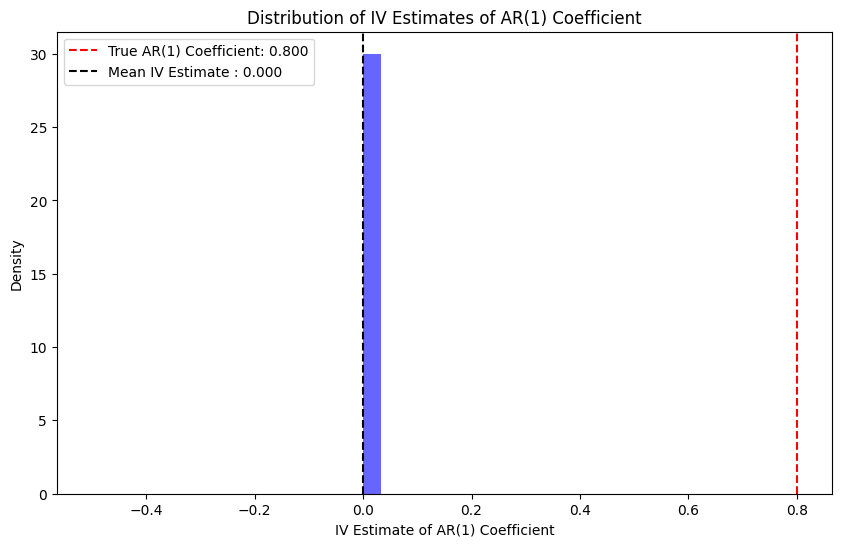

In [7]:
# Plot histogram of IV estimates
plt.figure(figsize=(10, 6))
plt.hist(iv_results, bins=30, density=True, alpha=0.6, color='b')
plt.title('Distribution of IV Estimates of AR(1) Coefficient')
plt.xlabel('IV Estimate of AR(1) Coefficient')
plt.ylabel('Density')
plt.axvline(x=phi, color='r', linestyle='--', label=f'True AR(1) Coefficient: {phi:.3f}')
plt.axvline(x=np.mean(iv_results), color='k', linestyle='--', label=f'Mean IV Estimate : {np.mean(iv_results):.3f}')
plt.legend()
plt.show()

The parameter is slightly biaised to the left. One can verify it is the Kendall biais, showing consitency of the IV estimator with the classic OLS estimator.

## Exercise 2

We know want to estimate an AR(3) process with an AR(1) model. This mispecification will bring the ommited variable problem. Here, the errors will contain the larger lag dependency and will be correlated with the error, breaking the exogeneity condition. The OLS estimate will probabiliy be biaised and inconsistent. We will show issue here that the errors will be serially correlated with a LDV. Here, we will keep the Monte Carlo simulation from exercise 1.

## Exercise 3 (omitted-variable bias)

True model (from the problem set):
$$
y_i = x_{1,i} + x_{2,i} + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)
$$


where $x_{1,i} \sim \mathcal{N}(0,1)$, $x_{2,i} \sim \mathcal{N}(0,1)$, and $\mathrm{Cov}(x_{1,i}, x_{2,i}) = 0$.

**(a)** Run **1,000 Monte Carlo simulations** (`T`); each replication uses **sample size 1,000** (`N`). In (a), independent draws of `x1` and `x2` enforce **zero correlation**; in (b)–(c) we change that correlation. The code cells simulate \(y_i\) and run **misspecified** OLS of \(y\) on \(x_1\) only (omitting \(x_2\)).


In [28]:
# Exercise 3(a): DGP — T replications, N observations each (per problem set)
T = 1000   # number of simulations
N = 1000   # sample size per simulation


def draw_exercise3_sample(n: int, corr_x1_x2: float = 0.0):
    """yi = x1i + x2i + epsi; eps ~ N(0,1); x1, x2 ~ N(0,1) with Corr(x1, x2) = corr_x1_x2 (default 0)."""
    x1 = np.random.standard_normal(n)
    z = np.random.standard_normal(n)
    rho = float(corr_x1_x2)
    if rho == 0.0:
        x2 = z
    else:
        x2 = rho * x1 + np.sqrt(1.0 - rho * rho) * z
    eps = np.random.standard_normal(n)
    y = x1 + x2 + eps
    return y, x1, x2, eps


# One example sample (same structure you will loop over for OLS in (a))
y, x1, x2, eps = draw_exercise3_sample(N)
print("Shapes:", y.shape, x1.shape, x2.shape)
print("Sample corr(x1, x2) ~ 0:", float(np.corrcoef(x1, x2)[0, 1]))
print("Sample mean y (theory E[y]=0):", float(np.mean(y)))


Shapes: (1000,) (1000,) (1000,)
Sample corr(x1, x2) ~ 0: -0.05212719805694232
Sample mean y (theory E[y]=0): 0.002810322642440358


Exercise 3(a) MC: 100%|██████████| 1000/1000 [00:32<00:00, 30.58it/s]


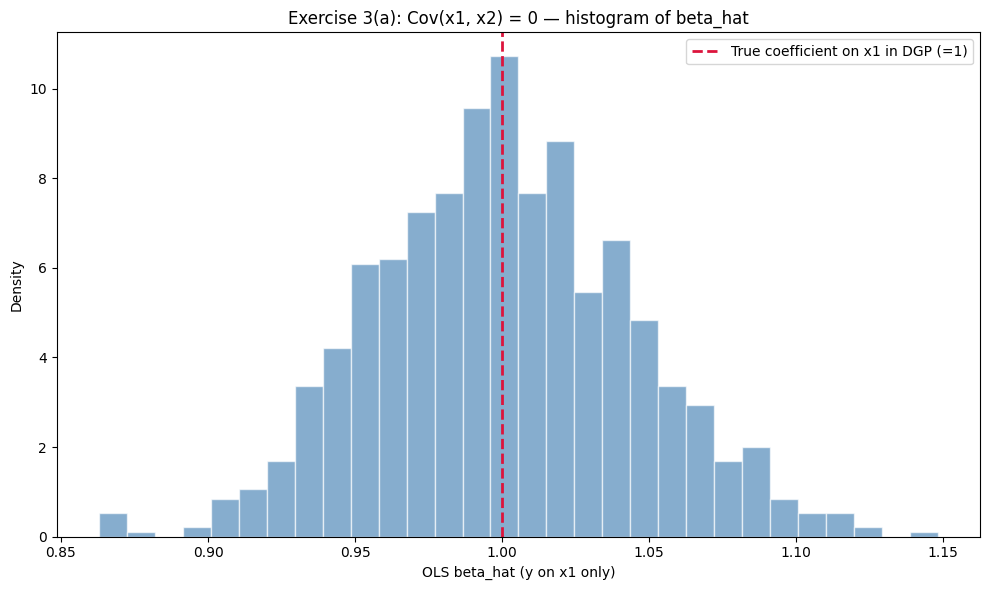

Mean beta_hat: 1.000332484572036
Std beta_hat: 0.043782736009115884


In [ ]:
# Exercise 3(a): misspecified OLS — regress y on x1 only (x2 omitted); T × N Monte Carlo
MC_SEED = 12345
np.random.seed(MC_SEED)
beta_hat_3a = np.zeros(T)

for i in tqdm(range(T), desc="Exercise 3(a) MC"):
    y_i, x1_i, x2_i, _eps = draw_exercise3_sample(N, corr_x1_x2=0.0)
    X = x1_i.reshape(-1, 1)
    fit = ols(X, y_i, include_constant=False)
    beta_hat_3a[i] = float(fit["beta_hat"].ravel()[0])

plt.figure(figsize=(10, 6))
plt.hist(beta_hat_3a, bins=30, density=True, alpha=0.65, color="steelblue", edgecolor="white")
plt.axvline(1.0, color="crimson", linestyle="--", linewidth=2, label="True coefficient on x1 in DGP (=1)")
plt.xlabel("OLS beta_hat (y on x1 only)")
plt.ylabel("Density")
plt.title("Exercise 3(a): Cov(x1, x2) = 0 — histogram of beta_hat")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean beta_hat:", float(np.mean(beta_hat_3a)))
print("Std beta_hat:", float(np.std(beta_hat_3a)))


The sampling distribution of $\hat{\beta}$ is approximately normal for $N=1000$, which is consistent with the asymptotic normality of OLS (Central Limit Theorem). In part (a), $\mathrm{Corr}(x_1,x_2)=0$ implies $\mathbb{E}[\varepsilon_i + x_{2,i}\mid x_{1,i}]=0$ in the short regression error, so OLS is unbiased for the true structural coefficient $\beta_1=1$ (the histogram is centered at 1.


### Exercise 3(b)

Repeat the same misspecified OLS ($y$ on $x_1$ only), but draw $(x_{1,i}, x_{2,i})$ so that **$\mathrm{Corr}(x_1, x_2) = 0.5$** (still $\mathcal{N}(0,1)$ marginals). The true DGP for $y$ is unchanged: $y_i = x_{1,i} + x_{2,i} + \varepsilon_i$.


Exercise 3(b) MC:   0%|          | 0/1000 [00:00<?, ?it/s]

Exercise 3(b) MC: 100%|██████████| 1000/1000 [00:37<00:00, 26.75it/s]


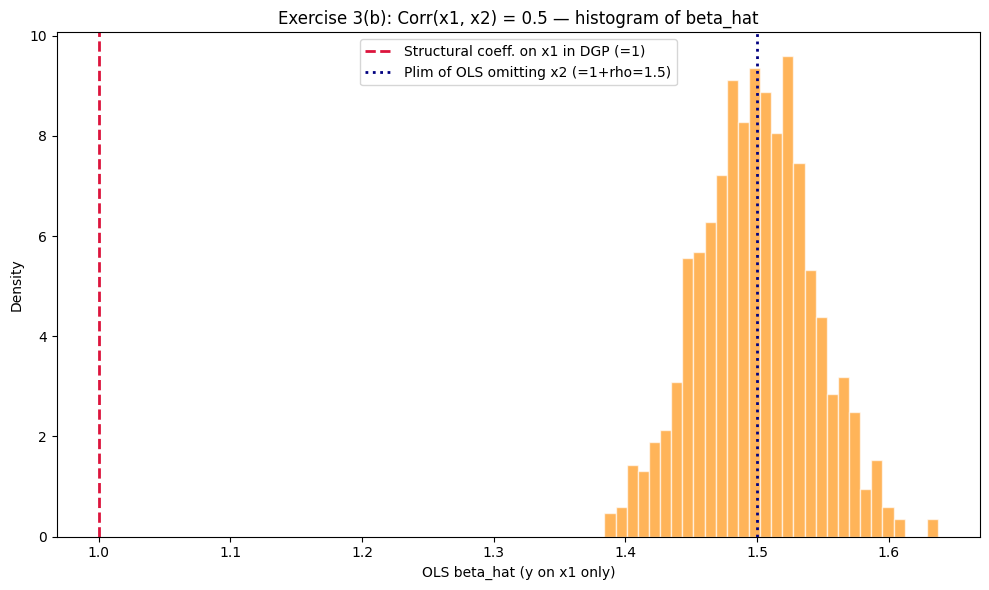

Mean beta_hat: 1.4992273881632923
Std beta_hat: 0.042858727681564915
Plim of OLS (omit x2, rho=0.5): 1.5


In [31]:
# Exercise 3(b): same Monte Carlo, Corr(x1, x2) = 0.5
RHO = 0.5
MC_SEED_B = MC_SEED + 1
np.random.seed(MC_SEED_B)
beta_hat_3b = np.zeros(T)

for i in tqdm(range(T), desc="Exercise 3(b) MC"):
    y_i, x1_i, x2_i, _eps = draw_exercise3_sample(N, corr_x1_x2=RHO)
    X = x1_i.reshape(-1, 1)
    fit = ols(X, y_i, include_constant=False)
    beta_hat_3b[i] = float(fit["beta_hat"].ravel()[0])

# Short regression omitting x2: plim beta_hat = 1 + Corr(x1,x2) when x1,x2 standardized and y=x1+x2+eps
plim_beta = 1.0 + RHO

plt.figure(figsize=(10, 6))
plt.hist(beta_hat_3b, bins=30, density=True, alpha=0.65, color="darkorange", edgecolor="white")
plt.axvline(1.0, color="crimson", linestyle="--", linewidth=2, label="Structural coeff. on x1 in DGP (=1)")
plt.axvline(plim_beta, color="navy", linestyle=":", linewidth=2, label=f"Plim of OLS omitting x2 (=1+rho={plim_beta})")
plt.xlabel("OLS beta_hat (y on x1 only)")
plt.ylabel("Density")
plt.title("Exercise 3(b): Corr(x1, x2) = 0.5 — histogram of beta_hat")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean beta_hat:", float(np.mean(beta_hat_3b)))
print("Std beta_hat:", float(np.std(beta_hat_3b)))
print("Plim of OLS (omit x2, rho=0.5):", plim_beta)


The sampling distribution of $\hat{\beta}$ is approximately normal for $N=1000$, which is consistent with the asymptotic normality of OLS (Central Limit Theorem). In part (b), $\mathrm{Corr}(x_1,x_2)=0.5$ implies $\mathbb{E}[x_{2,i}+\varepsilon_i \mid x_{1,i}]$ is not identically zero (it varies with $x_{1,i}$), so the error in the short regression is correlated with $x_1$ and OLS is biased and inconsistent for the true structural coefficient $\beta_1=1$; the histogram is centered near the short-regression probability limit $1+\rho=1.5$.


### Exercise 3(c)

Exercise 3(b) MC: 100%|██████████| 1000/1000 [00:38<00:00, 26.31it/s]


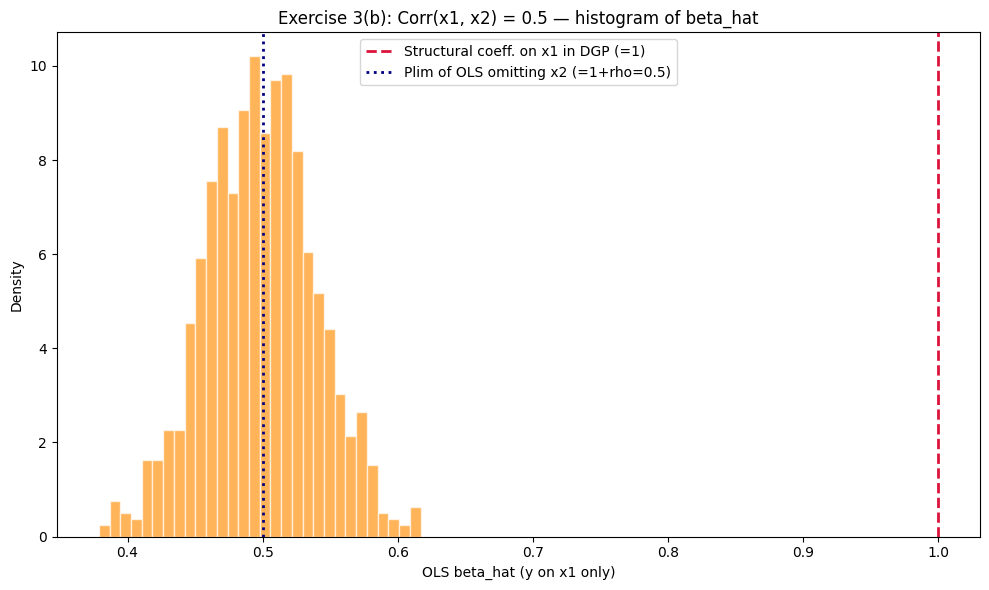

Mean beta_hat: 0.4981732409720902
Std beta_hat: 0.04075178768937591
Plim of OLS (omit x2, rho=0.5): 0.5


In [ ]:
# Exercise 3(c): same Monte Carlo, Corr(x1, x2) = -0.5
RHO = -0.5
MC_SEED_C = MC_SEED_B + 1
np.random.seed(MC_SEED_C)
beta_hat_3b = np.zeros(T)

for i in tqdm(range(T), desc="Exercise 3(b) MC"):
    y_i, x1_i, x2_i, _eps = draw_exercise3_sample(N, corr_x1_x2=RHO)
    X = x1_i.reshape(-1, 1)
    fit = ols(X, y_i, include_constant=False)
    beta_hat_3b[i] = float(fit["beta_hat"].ravel()[0])

# Short regression omitting x2: plim beta_hat = 1 + Corr(x1,x2) when x1,x2 standardized and y=x1+x2+eps
plim_beta = 1.0 + RHO

plt.figure(figsize=(10, 6))
plt.hist(beta_hat_3b, bins=30, density=True, alpha=0.65, color="darkorange", edgecolor="white")
plt.axvline(1.0, color="crimson", linestyle="--", linewidth=2, label="Structural coeff. on x1 in DGP (=1)")
plt.axvline(plim_beta, color="navy", linestyle=":", linewidth=2, label=f"Plim of OLS omitting x2 (=1+rho={plim_beta})")
plt.xlabel("OLS beta_hat (y on x1 only)")
plt.ylabel("Density")
plt.title("Exercise 3(c): Corr(x1, x2) = 0.5 — histogram of beta_hat")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean beta_hat:", float(np.mean(beta_hat_3b)))
print("Std beta_hat:", float(np.std(beta_hat_3b)))
print("Plim of OLS (omit x2, rho=0.5):", plim_beta)


the same violation of the property of the OLS (consistency and unbiasness) for question (b) applies to (c)

### Exercice 3(d)

For 
$$
y = X_1\beta_1 + X_2\beta_2 + u.
$$

The **Frisch–Waugh (FW)** theorem states that $\hat{\beta}_1$ from OLS using $(X_1, X_2)$ can be computed in **two steps**:

1. **Partial out** $X_2$: Form residuals $\tilde{X}_1 = M_{X_2} X_1$ and $\tilde{y} = M_{X_2} y$, where
   $$
   M_{X_2} = I - X_2 (X_2' X_2)^{-1} X_2'
   $$
   projects out the linear component explainable by $X_2$.
2. Regress $\tilde{y}$ on $\tilde{X}_1$: 
   $$
   \hat{\beta}_1 = (\tilde{X}_1' \tilde{X}_1)^{-1} \tilde{X}_1' \tilde{y}
   $$

**Interpretation:** $\hat{\beta}_1$ measures how $y$ moves with the part of $X_1$ that is **orthogonal** to $X_2$—that is, the effect of $X_1$ **after controlling for** $X_2$.

here, The Monte Carlo **short** regression uses only $x_1$. Compared with FW, that's like **not** projecting $x_1$ off $x_2$ before attributing variation in $y$ to $x_1$.

- **When $\mathrm{Corr}(x_1, x_2) = 0$** (part (a)), $x_1$ is already orthogonal to $x_2$, so $M_{x_2} x_1$ is proportional to $x_1$. The omitted $x_2$ does **not** bias the coefficient on $x_1$: the short regression still recovers the **structural** coefficient on $x_1$ in this linear setup (namely, **1**).

- **When $\mathrm{Corr}(x_1, x_2) \neq 0$** (parts (b)–(c)), the part of $y$ that comes through correlated $x_2$ is **mis-attributed** to $x_1$. The short-regression estimand differs from **1** (in our DGP with unit coefficients and standardized variables, $\mathrm{plim}\; \hat{\beta} = 1 + \rho$).

Thus, FW makes precise what goes wrong when you omit $x_2$: you skip the **residualization / control** step whenever $x_2$ shares linear variation with $x_1$, which is exactly when **omitted-variable bias** causes bias and inconsistency for the true $\beta_1$ from the full model.